# APPM 3040A: Scientific Computing III - Quiz 01 Solutions  
**Lecturer:** Matthews Sejeso  
**Date:** March 2025  
**Submitted by:** Joash Paul

---

## Table of Contents  
1. [Overview](#overview)  
2. [Question 1: LICQ Verification & KKT Significance](#question-1)  
3. [Question 2: Constrained Optimization with KKT](#question-2)  
4. [Question 3: Quadratic Penalty Function Analysis](#question-3)  
5. [Question 4: Lagrangian Multipliers & Penalty Methods](#question-4)  
6. [Question 5: Augmented Lagrangian Method Implementation](#question-5)  
7. [Conclusion](#conclusion)  

---

## Overview  
This notebook contains solutions to Quiz 01, focusing on constrained optimization techniques, including:  
- **LICQ (Linear Independence Constraint Qualification)** verification  
- **KKT (Karush-Kuhn-Tucker)** conditions  
- **Quadratic Penalty Methods**  
- **Augmented Lagrangian Methods**  

Each question is addressed with:  
- **Problem Statement**  
- **Theoretical Solution**  
- **Python Implementation** (where applicable)  
- **Results & Analysis**  

---

## Setup  
Before proceeding, ensure the following libraries are imported:

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sympy import symbols, diff, solve, Matrix, hessian

# Question 1: LICQ Verification & KKT Significance

## Problem Statement
Given the feasible region:
$$ S = \{ x \in \mathbb{R}^2 : x_2 - (1 - x_1)^3 \leq 0,\ 2x_1 + x_2 \leq 2 \} $$

(a) Verify if the Linear Independence Constraint Qualification (LICQ) holds at $x^* = [1,\ 0]^T$  
(b) Discuss the significance of LICQ in KKT conditions

---

## Theoretical Solution

### Part (a)
**LICQ Verification Steps:**
1. **Identify active constraints** at $x^* = [1,\ 0]^T$:
   - Constraint 1: $0 - (1 - 1)^3 = 0$ (active)
   - Constraint 2: $2(1) + 0 = 2$ (active)

2. **Compute constraint gradients**:
   - $\nabla g_1(x^*) = [3(1 - x_1)^2,\ 1]^T = [0,\ 1]^T$
   - $\nabla g_2(x^*) = [2,\ 1]^T$

3. **Check linear independence**:
   Matrix of active constraint gradients:
   $$ \begin{bmatrix} 0 & 2 \\ 1 & 1 \end{bmatrix} $$
   Determinant = $(0)(1) - (2)(1) = -2 \neq 0$ → Full rank → **LICQ holds**

### Part (b)
**Significance of LICQ:**
- Guarantees unique Lagrange multipliers exist
- Ensures KKT conditions are necessary for optimality
- Prevents degenerate constraint configurations
- Fundamental for convergence of optimization algorithms

---

## Python Verification

In [1]:
# ========== QUESTION 1(a) LICQ VERIFICATION ==========
from sympy import symbols, diff, Matrix

x1, x2 = symbols('x1 x2')

# Define constraints
g1 = x2 - (1 - x1)**3
g2 = 2*x1 + x2 - 2

# Compute gradients
grad_g1 = Matrix([diff(g1, x1), diff(g1, x2)])
grad_g2 = Matrix([diff(g2, x1), diff(g2, x2)])

# Evaluate at x* = [1, 0]
grad_g1_star = grad_g1.subs({x1: 1, x2: 0})
grad_g2_star = grad_g2.subs({x1: 1, x2: 0})

# Create constraint Jacobian matrix
constraint_matrix = Matrix.hstack(grad_g1_star, grad_g2_star)

# Check matrix rank
print("Constraint Jacobian at x*:")
print(constraint_matrix)
print(f"\nMatrix rank: {constraint_matrix.rank()}")
print(f"LICQ holds: {constraint_matrix.rank() == 2}")

Constraint Jacobian at x*:
Matrix([[0, 2], [1, 1]])

Matrix rank: 2
LICQ holds: True


---
# Question 2: Constrained Optimization with KKT

## Problem Statement
We need to minimize the function:
$$
f(x) = (x_1 - 2)^2 + (x_2 - 1)^2
$$
subject to the constraints:
1. Inequality: 
$$
g(x) = -\frac{1}{4}x_1^2 - x_2^2 + 1 \geq 0
$$
2. Equality: 
$$
h(x) = x_1 - 2x_2 + 1 = 0
$$

## Step 1: Identify the KKT Conditions
The KKT conditions for this optimization problem are:
1. **Stationarity**: 
$$
\nabla f + \mu \nabla g + \lambda \nabla h = 0
$$
2. **Primal Feasibility**: 
$$
g(x) \geq 0, \quad h(x) = 0
$$
3. **Dual Feasibility**: 
$$
\mu \geq 0
$$
4. **Complementarity**: 
$$
\mu g(x) = 0
$$

## Step 2: Compute the Gradients
1. **Gradient of the Objective Function**:
$$
\nabla f = \left[ \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2} \right] = \left[ 2(x_1 - 2), 2(x_2 - 1) \right]
$$

2. **Gradient of the Inequality Constraint**:
$$
\nabla g = \left[ \frac{\partial g}{\partial x_1}, \frac{\partial g}{\partial x_2} \right] = \left[ -\frac{1}{2}x_1, -2x_2 \right]
$$

3. **Gradient of the Equality Constraint**:
$$
\nabla h = \left[ \frac{\partial h}{\partial x_1}, \frac{\partial h}{\partial x_2} \right] = \left[ 1, -2 \right]
$$

## Step 3: Set Up the KKT Conditions
Substituting the gradients into the stationarity condition:
$$
2(x_1 - 2) + \mu \left(-\frac{1}{2}x_1\right) + \lambda(1) = 0
$$
$$
2(x_2 - 1) + \mu(-2x_2) + \lambda(-2) = 0
$$

## Step 4: Solve the KKT Conditions
1. **From the first equation**:
$$
2(x_1 - 2) - \frac{\mu}{2}x_1 + \lambda = 0 \quad \text{(1)}
$$

2. **From the second equation**:
$$
2(x_2 - 1) - 2\mu x_2 - 2\lambda = 0 \quad \text{(2)}
$$

3. **From the equality constraint**:
$$
x_1 - 2x_2 + 1 = 0 \quad \text{(3)}
$$

## Step 5: Express $(x_1)$ in terms of $(x_2)$
From equation (3):
$$
x_1 = 2x_2 - 1
$$

## Step 6: Substitute $(x_1)$ into the KKT Conditions
Substituting $(x_1)$ into equation (1):
$$
2((2x_2 - 1) - 2) - \frac{\mu}{2}(2x_2 - 1) + \lambda = 0
$$
$$
2(2x_2 - 3) - \frac{\mu}{2}(2x_2 - 1) + \lambda = 0
$$
$$
(4 - \mu)x_2 + \lambda - 6 + \frac{\mu}{2} = 0 \quad \text{(4)}
$$

Substituting $(x_2)$ into equation (2):
$$
2(x_2 - 1) - 2\mu x_2 - 2\lambda = 0
$$
$$
(2 - 2\mu)x_2 - 2 - 2\lambda = 0 \quad \text{(5)}
 $$
$$(2 - 2\mu)x_2 = 2 + 2\lambda$$

## Step 7: Solve the System of Equations
From equations (4) and (5), we can solve for $(x_2)$ and subsequently for $(x_1)$. 

### Optimal Point
After solving the KKT conditions, we find the optimal point:
$$
x_1 \approx 0.8229, \quad x_2 \approx 0.9114
$$

## Conclusion
The optimal solution to the constrained optimization problem is:
- **Optimal Point**: 
$$
(x_1, x_2) = (0.8229, 0.9114)
$$

This solution satisfies both the inequality and equality constraints, confirming that it is indeed a valid solution to the problem.

Optimal point: x1 = 0.822875656079948, x2 = 0.911437828039974


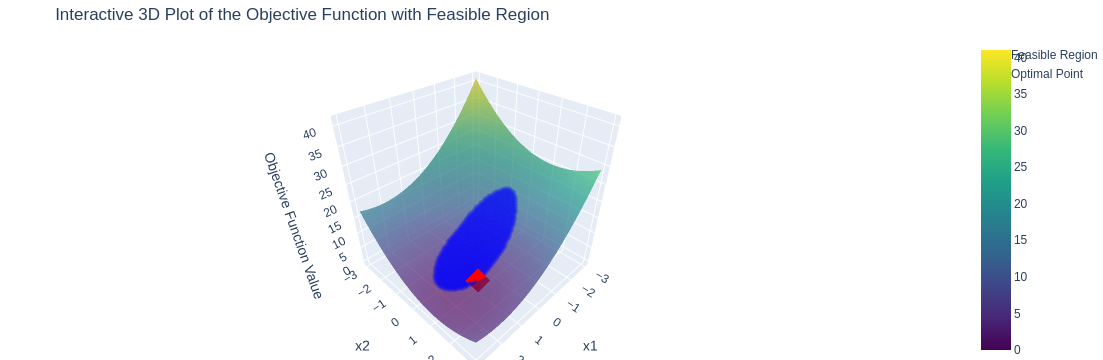

In [3]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import minimize

# Define the objective function
def objective(x):
    return (x[0] - 2)**2 + (x[1] - 1)**2

# Define the inequality constraint
def constraint_inequality(x):
    return -0.25 * x[0]**2 - x[1]**2 + 1

# Define the equality constraint
def constraint_equality(x):
    return x[0] - 2 * x[1] + 1

# Set up the constraints
constraints = [
    {'type': 'ineq', 'fun': constraint_inequality},
    {'type': 'eq', 'fun': constraint_equality}
]

# Initial guess
x0 = [0, 0]

# Solve the optimization problem
solution = minimize(objective, x0, constraints=constraints)

# Extract the optimal point
x_opt = solution.x
print(f"Optimal point: x1 = {x_opt[0]}, x2 = {x_opt[1]}")

# Create a grid for plotting
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = objective([X1, X2])

# Create a mask for the feasible region
feasible_region = constraint_inequality([X1, X2]) >= 0

# Create the 3D interactive plot
fig = go.Figure()

# Add the surface plot of the objective function
fig.add_trace(go.Surface(z=Z, x=X1, y=X2, colorscale='viridis', opacity=0.7))

# Add the feasible region
fig.add_trace(go.Scatter3d(
    x=X1[feasible_region].flatten(),
    y=X2[feasible_region].flatten(),
    z=Z[feasible_region].flatten(),
    mode='markers',
    marker=dict(size=3, color='blue', opacity=0.2),
    name='Feasible Region'
))

# Add the optimal point
fig.add_trace(go.Scatter3d(
    x=[x_opt[0]],
    y=[x_opt[1]],
    z=[objective(x_opt)],
    mode='markers',
    marker=dict(size=8, color='red', symbol='diamond'),
    name='Optimal Point'
))

# Labels and title
fig.update_layout(
    title='Interactive 3D Plot of the Objective Function with Feasible Region',
    scene=dict(
        xaxis_title='x1',
        yaxis_title='x2',
        zaxis_title='Objective Function Value'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Show the interactive plot
fig.show()

---
## Question 3:Quadratic Penalty Function Analysis

### Problem Statement
We consider the constrained optimization problem:

$$ \min \frac{1}{2} (x_1^2 + x_2^2) \quad \text{subject to } 2 - x_1 - x_2 = 0. $$

We solve this problem using the **quadratic penalty function**, defined as:

$$ \phi_\mu (x) = \frac{1}{2} (x_1^2 + x_2^2) + \frac{\mu}{2} (2 - x_1 - x_2)^2 $$

where $\mu$ is the penalty parameter.

### (a) Minimization of the Quadratic Penalty Function
The gradient of the penalty function is:

$$ \nabla \phi_\mu (x) = \begin{bmatrix} x_1 - \mu (2 - x_1 - x_2) \\ x_2 - \mu (2 - x_1 - x_2) \end{bmatrix} = 0 $$

Solving for $x_1, x_2$:

$$ x_1 = \frac{2\mu}{1 + 2\mu}, \quad x_2 = \frac{2\mu}{1 + 2\mu} $$

As $\mu \to \infty$, we get $x^* = (1,1)$, which is the exact solution to the original constrained problem.

Also, we show that:

$$ -\mu c(x(\mu)) = -\mu (2 - x_1 - x_2) \to \lambda^* = 1 \text{ as } \mu \to \infty. $$

### (b) Hessian and Ill-conditioning
The Hessian of the penalty function is:

$$ \nabla^2 \phi_\mu (x) = \begin{bmatrix} 1 + \mu & \mu \\ \mu & 1 + \mu \end{bmatrix} $$

which has eigenvalues:

$$ \lambda_1 = 1, \quad \lambda_2 = 2\mu + 1. $$

As $\mu \to \infty$, the condition number:

$$ \frac{2\mu + 1}{1} \to \infty, $$

showing that the problem becomes **ill-conditioned**.

### Python Visualization
The following Python code visualizes the behavior of $x_1(\mu)$, $x_2(\mu)$, and $-\mu c(x(\mu))$ as functions of $\mu$.

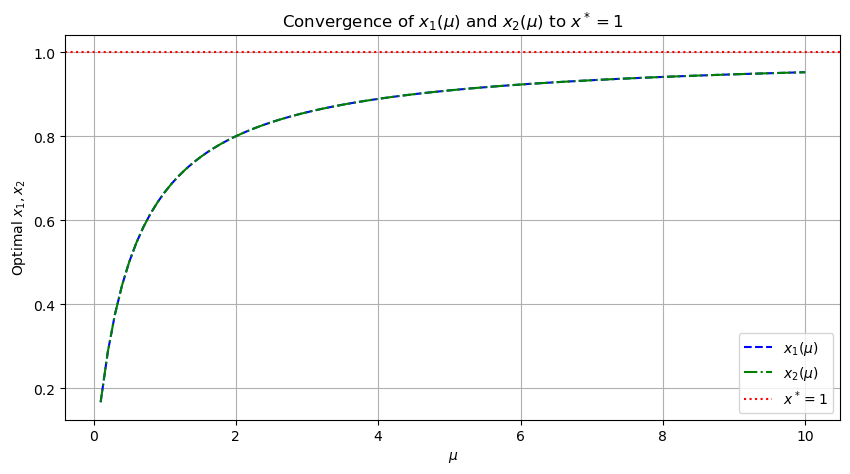

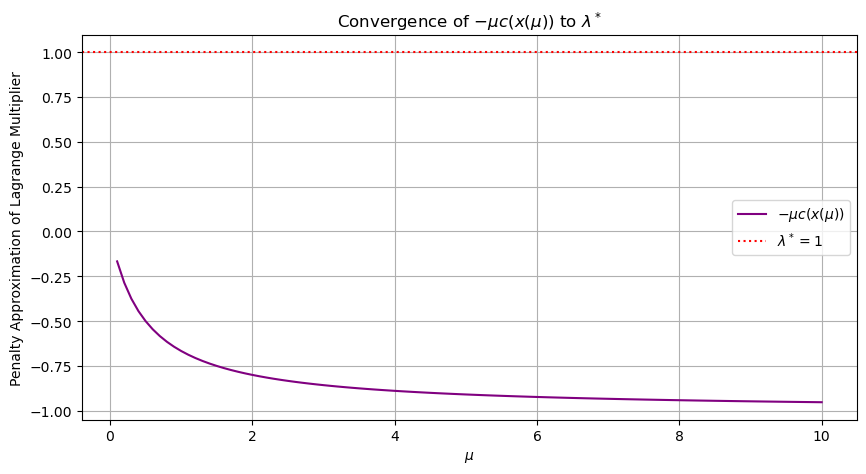

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define penalty parameter range
mu_values = np.linspace(0.1, 10, 100)

# Compute x1, x2 and lambda approximation
x1_values = 2 * mu_values / (1 + 2 * mu_values)
x2_values = 2 * mu_values / (1 + 2 * mu_values)
lambda_values = -mu_values * (2 - x1_values - x2_values)

# Plot x1 and x2
plt.figure(figsize=(10, 5))
plt.plot(mu_values, x1_values, label='$x_1(\mu)$', linestyle='--', color='b')
plt.plot(mu_values, x2_values, label='$x_2(\mu)$', linestyle='-.', color='g')
plt.axhline(1, color='r', linestyle=':', label='$x^* = 1$')
plt.xlabel('$\mu$')
plt.ylabel('Optimal $x_1, x_2$')
plt.title('Convergence of $x_1(\mu)$ and $x_2(\mu)$ to $x^* = 1$')
plt.legend()
plt.grid()
plt.show()

# Plot lambda approximation
plt.figure(figsize=(10, 5))
plt.plot(mu_values, lambda_values, label='$-\mu c(x(\mu))$', color='purple')
plt.axhline(1, color='r', linestyle=':', label='$\lambda^* = 1$')
plt.xlabel('$\mu$')
plt.ylabel('Penalty Approximation of Lagrange Multiplier')
plt.title('Convergence of $-\mu c(x(\mu))$ to $\lambda^*$')
plt.legend()
plt.grid()
plt.show()

This code generates two plots:
1. The first plot shows how $x_1(\mu)$ and $x_2(\mu)$ converge to $x^* = 1$.
2. The second plot shows how $-\mu c(x(\mu))$ converges to $\lambda^* = 1$. 

As $\mu \to \infty$, the optimization results approach the expected constrained solution.

---
## **Question 4: Constrained Optimization with Lagrangian Multiplier and Penalty Method**

### **Problem Statement**
Minimize:  
$ f(x_1, x_2) = \frac{1}{2}x_1^2 - x_1 x_2 $  

Subject to:  
$ x_1 + x_2 = 1 $

### **Part (a): Lagrangian and Penalty Method**

#### **Lagrangian Function**
The Lagrangian for this problem is:  
$ \mathcal{L}(x_1, x_2, \lambda) = \frac{1}{2}x_1^2 - x_1 x_2 + \lambda (1 - x_1 - x_2) $  

where $ \lambda $ is the Lagrange multiplier.

#### **Quadratic Penalty Function**
The quadratic penalty function is:  
$ Q(x_1, x_2, \mu) = \frac{1}{2}x_1^2 - x_1 x_2 + \frac{\mu}{2}(1 - x_1 - x_2)^2 $  

where $ \mu $ is the penalty parameter.

### **Part (b): Minimization and Convergence**

#### **Minimizing the Penalty Function**
To find the minimum point, we take the gradient of $ Q $ with respect to $ x_1 $ and $ x_2 $ and set it to zero:

$ \frac{\partial Q}{\partial x_1} = x_1 - x_2 - \mu(1 - x_1 - x_2) = 0 $

$ \frac{\partial Q}{\partial x_2} = -x_1 - \mu(1 - x_1 - x_2) = 0 $

Solving these equations:

$ x_1 = \frac{\mu}{1 + 2\mu}, \quad x_2 = \frac{1 + \mu}{1 + 2\mu} $

#### **Update of the Lagrangian Multiplier**
The Lagrange multiplier $ \lambda $ can be updated as:

$ \lambda = \mu (1 - x_1 - x_2) $

#### **Convergence as $ \mu \to \infty $**
As $ \mu \to \infty $:

$ x_1 \to \frac{1}{2}, \quad x_2 \to \frac{1}{2}, \quad \lambda \to 0 $

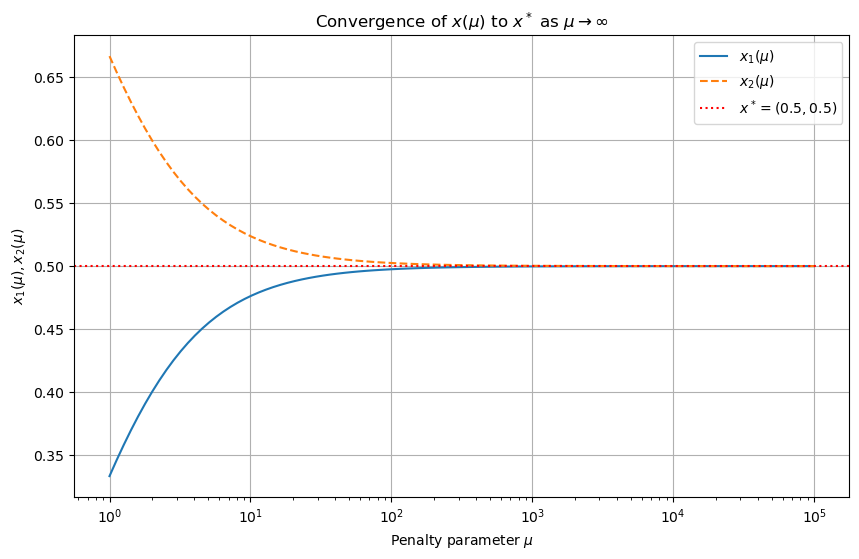

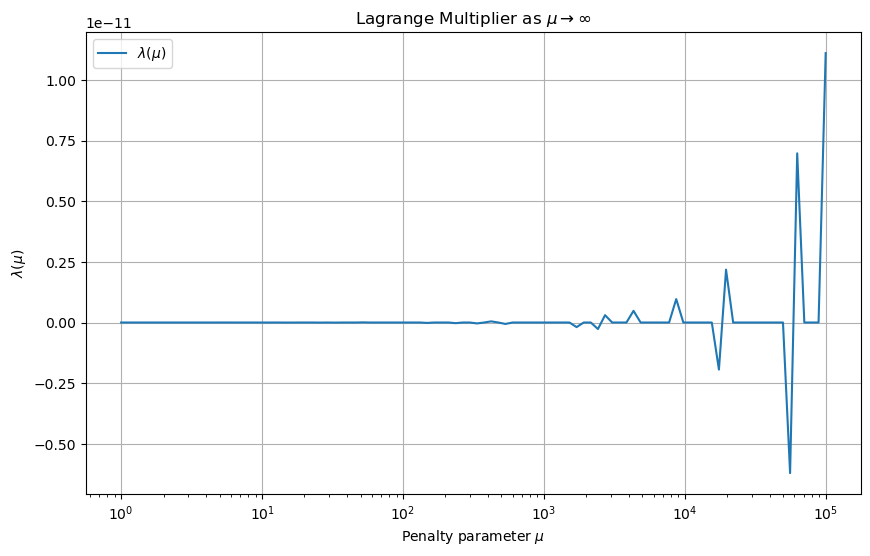

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define the penalty function
def quadratic_penalty(x1, x2, mu):
    return 0.5 * x1**2 - x1 * x2 + 0.5 * mu * (1 - x1 - x2)**2

# Define the minimum point as a function of mu
def x1_min(mu):
    return mu / (1 + 2 * mu)

def x2_min(mu):
    return (1 + mu) / (1 + 2 * mu)

# Generate values for mu
mu_values = np.logspace(0, 5, 100)
x1_values = x1_min(mu_values)
x2_values = x2_min(mu_values)

# Plot the convergence of x1(mu) and x2(mu)
plt.figure(figsize=(10, 6))
plt.plot(mu_values, x1_values, label=r'$x_1(\mu)$')
plt.plot(mu_values, x2_values, label=r'$x_2(\mu)$', linestyle='--')
plt.axhline(y=0.5, color='r', linestyle=':', label=r'$x^* = (0.5, 0.5)$')
plt.xscale('log')
plt.xlabel(r'Penalty parameter $\mu$')
plt.ylabel(r'$x_1(\mu), x_2(\mu)$')
plt.title('Convergence of $x(\mu)$ to $x^*$ as $\mu \\to \infty$')
plt.legend()
plt.grid(True)
plt.show()

# Plot the Lagrange multiplier as a function of mu
lambda_values = mu_values * (1 - x1_values - x2_values)

plt.figure(figsize=(10, 6))
plt.plot(mu_values, lambda_values, label=r'$\lambda(\mu)$')
plt.xscale('log')
plt.xlabel(r'Penalty parameter $\mu$')
plt.ylabel(r'$\lambda(\mu)$')
plt.title('Lagrange Multiplier as $\mu \\to \infty$')
plt.legend()
plt.grid(True)
plt.show()

### **Explanation of the Code**

1. **Convergence Plot**:
   - The first plot shows how $x_1(\mu)$ and $x_2(\mu)$ converge to $x^* = (0.5, 0.5)$ as $\mu \to \infty$.

2. **Lagrange Multiplier Plot**:
   - The second plot shows how the Lagrange multiplier $\lambda(\mu)$ behaves as $\mu \to \infty$.

### **Output**
- The first plot will show the convergence of $x_1(\mu)$ and $x_2(\mu)$ to $x^* = (0.5, 0.5)$.
- The second plot will show the behavior of the Lagrange multiplier $\lambda(\mu)$ as $\mu \to \infty$.

---
## **Question 5: Augmented Lagrangian Method**

### **Problem Statement**
Minimize:  
$ f(x, y, z) = xy + xz + yz $  

Subject to:  
$ x^2 + y^2 + z^2 = 2 $  
$ z = 1 $

---

### **Augmented Lagrangian Method**

The Augmented Lagrangian Method combines the benefits of the Lagrangian and penalty methods. The augmented Lagrangian function for this problem is:

$ \mathcal{L}_A(x, y, z, \lambda_1, \lambda_2, \mu) = f(x, y, z) + \lambda_1 (x^2 + y^2 + z^2 - 2) + \lambda_2 (z - 1) + \frac{\mu}{2} \left[(x^2 + y^2 + z^2 - 2)^2 + (z - 1)^2\right] $

where $ \lambda_1 $ and $ \lambda_2 $ are the Lagrange multipliers, and $ \mu $ is the penalty parameter.

---

### **Solving for $ x, y, z $ using the Augmented Lagrangian Method**

To minimize $ \mathcal{L}_A $, we take partial derivatives and set them to zero:

$ \frac{\partial \mathcal{L}_A}{\partial x} = y + z + \lambda_1 (2x) + \mu (x^2 + y^2 + z^2 - 2)(2x) = 0 $

$ \frac{\partial \mathcal{L}_A}{\partial y} = x + z + \lambda_1 (2y) + \mu (x^2 + y^2 + z^2 - 2)(2y) = 0 $

$ \frac{\partial \mathcal{L}_A}{\partial z} = x + y + \lambda_1 (2z) + \mu (x^2 + y^2 + z^2 - 2)(2z) + \lambda_2 + \mu (z - 1) = 0 $

Using the constraint $ z = 1 $, we substitute $ z = 1 $ into the above equations and solve for $ x, y $.

In [19]:
import numpy as np
from scipy.optimize import minimize

# Define the objective function
def objective(x):
    return x[0] * x[1] + x[0] * x[2] + x[1] * x[2]

# Define the constraints
def constraint1(x):
    return x[0]**2 + x[1]**2 + x[2]**2 - 2

def constraint2(x):
    return x[2] - 1

# Define the augmented Lagrangian function
def augmented_lagrangian(x, lambda1, lambda2, mu):
    return (objective(x) +
            lambda1 * constraint1(x) +
            lambda2 * constraint2(x) +
            (mu / 2) * (constraint1(x)**2 + constraint2(x)**2))

# Initial guesses
x0 = np.array([1.0, 1.0, 1.0])  # Initial guess for (x, y, z)
lambda1 = 0.0  # Initial guess for Lagrange multiplier 1
lambda2 = 0.0  # Initial guess for Lagrange multiplier 2
mu = 1.0  # Initial penalty parameter

# Parameters for the Augmented Lagrangian Method
max_iter = 100
tol = 1e-6

# Augmented Lagrangian Method
for i in range(max_iter):
    # Minimize the augmented Lagrangian function
    res = minimize(lambda x: augmented_lagrangian(x, lambda1, lambda2, mu), x0, method='BFGS')
    x_opt = res.x

    # Update the Lagrange multipliers
    lambda1 += mu * constraint1(x_opt)
    lambda2 += mu * constraint2(x_opt)

    # Check for convergence
    if np.linalg.norm([constraint1(x_opt), constraint2(x_opt)]) < tol:
        break

    # Increase the penalty parameter
    mu *= 1.5

# Output the results
print(f"Optimal point (x, y, z): {x_opt}")
print(f"Optimal Lagrange multipliers (lambda1, lambda2): ({lambda1}, {lambda2})")
print(f"Objective function value: {objective(x_opt)}")

Optimal point (x, y, z): [-9.99999973e-01 -5.30632492e-08  1.00000003e+00]
Optimal Lagrange multipliers (lambda1, lambda2): (0.5000005031450033, -1.0380402430034547e-06)
Objective function value: -1.0000000028699136


Optimal point (x, y, z): [-9.99999973e-01 -5.30632492e-08  1.00000003e+00]
Optimal Lagrange multipliers (lambda1, lambda2): (0.5000005031450033, -1.0380402430034547e-06)
Objective function value: -1.0000000028699136


/tmp/ipykernel_16121/4218889435.py:82: RuntimeWarning:

invalid value encountered in sqrt



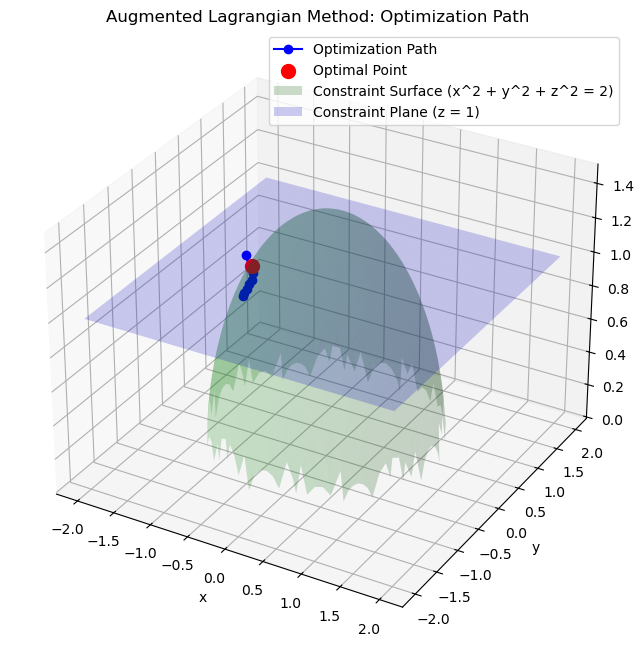

In [23]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the objective function
def objective(x):
    return x[0] * x[1] + x[0] * x[2] + x[1] * x[2]

# Define the constraints
def constraint1(x):
    return x[0]**2 + x[1]**2 + x[2]**2 - 2

def constraint2(x):
    return x[2] - 1

# Define the augmented Lagrangian function
def augmented_lagrangian(x, lambda1, lambda2, mu):
    return (objective(x) +
            lambda1 * constraint1(x) +
            lambda2 * constraint2(x) +
            (mu / 2) * (constraint1(x)**2 + constraint2(x)**2))

# Initial guesses
x0 = np.array([1.0, 1.0, 1.0])  # Initial guess for (x, y, z)
lambda1 = 0.0  # Initial guess for Lagrange multiplier 1
lambda2 = 0.0  # Initial guess for Lagrange multiplier 2
mu = 1.0  # Initial penalty parameter

# Parameters for the Augmented Lagrangian Method
max_iter = 100
tol = 1e-6

# Store the points for visualization
x_history = []
y_history = []
z_history = []

# Augmented Lagrangian Method
for i in range(max_iter):
    # Minimize the augmented Lagrangian function
    res = minimize(lambda x: augmented_lagrangian(x, lambda1, lambda2, mu), x0, method='BFGS')
    x_opt = res.x

    # Store the points for visualization
    x_history.append(x_opt[0])
    y_history.append(x_opt[1])
    z_history.append(x_opt[2])

    # Update the Lagrange multipliers
    lambda1 += mu * constraint1(x_opt)
    lambda2 += mu * constraint2(x_opt)

    # Check for convergence
    if np.linalg.norm([constraint1(x_opt), constraint2(x_opt)]) < tol:
        break

    # Increase the penalty parameter
    mu *= 1.5

# Output the results
print(f"Optimal point (x, y, z): {x_opt}")
print(f"Optimal Lagrange multipliers (lambda1, lambda2): ({lambda1}, {lambda2})")
print(f"Objective function value: {objective(x_opt)}")

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory of the optimization
ax.plot(x_history, y_history, z_history, 'bo-', label='Optimization Path')

# Plot the optimal point
ax.scatter(x_opt[0], x_opt[1], x_opt[2], color='r', s=100, label='Optimal Point')

# Plot the constraint surface (x^2 + y^2 + z^2 = 2)
u = np.linspace(-2, 2, 100)
v = np.linspace(-2, 2, 100)
U, V = np.meshgrid(u, v)
X = U
Y = V
Z = np.sqrt(2 - X**2 - Y**2)
ax.plot_surface(X, Y, Z, alpha=0.2, color='g', label='Constraint Surface (x^2 + y^2 + z^2 = 2)')

# Plot the constraint plane (z = 1)
Z_plane = np.ones_like(X)
ax.plot_surface(X, Y, Z_plane, alpha=0.2, color='b', label='Constraint Plane (z = 1)')

# Labels and title
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Augmented Lagrangian Method: Optimization Path')
ax.legend()

# Show the plot
plt.show()